# Student Performance Exploratory Data Analysis
This notebook explores the factors affecting student academic performance, such as study hours and attendance.

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/Student_data.csv')



## Data Inspection
First, let's look at the first few rows of the dataset to understand its structure.

In [27]:

df.head()

,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


## Missing Values and Data Types
Checking if there are any null values that need to be handled.

In [28]:

print("Missing values in each column:")
print(df.isnull().sum())


df.info()

Missing values in each column:
Student_ID             0
Gender                 0
Age                    0
Major                  0
Attendance_Pct         0
Study_Hours_Per_Day    0
Previous_GPA           0
Sleep_Hours            0
Social_Hours_Week      0
Final_CGPA             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5000 non-null   object 
 1   Gender               5000 non-null   object 
 2   Age                  5000 non-null   int64  
 3   Major                5000 non-null   object 
 4   Attendance_Pct       5000 non-null   float64
 5   Study_Hours_Per_Day  5000 non-null   float64
 6   Previous_GPA         5000 non-null   float64
 7   Sleep_Hours          5000 non-null   float64
 8   Social_Hours_Week    5000 non-null   int64  
 9   Final_CGPA           5000 non-null   float64

Observation: There are no missing values in this dataset.

In [29]:

df.describe()

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.948600,83.795740,4.517840,3.093824,7.012060,8.006400,3.272224
std,2.017417,12.867904,2.568104,0.476754,1.424377,2.797771,0.507954
min,18.000000,26.200000,0.100000,1.350000,4.000000,0.000000,1.160000
25%,19.000000,75.100000,2.600000,2.760000,6.000000,6.000000,2.920000
50%,21.000000,85.050000,4.000000,3.100000,7.000000,8.000000,3.310000
75%,23.000000,94.800000,6.000000,3.430000,8.000000,10.000000,3.680000
max,24.000000,100.000000,14.000000,4.000000,10.000000,20.000000,4.000000


In [30]:
print(df.columns.tolist())

['Student_ID', 'Gender', 'Age', 'Major', 'Attendance_Pct', 'Study_Hours_Per_Day', 'Previous_GPA', 'Sleep_Hours', 'Social_Hours_Week', 'Final_CGPA']



## Univariate Analysis: Distribution of Grades
In this section, we visualize the distribution of the target variable `Final_CGPA`.
This helps us understand if the grades are normally distributed or if there is any skewness in the data.

## Gender Distribution

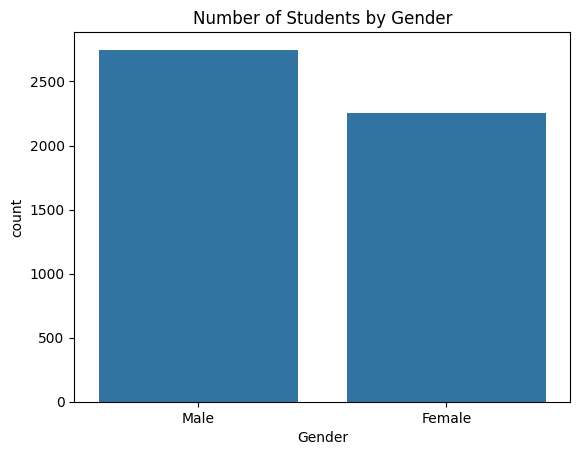

In [37]:

sns.countplot(x='Gender', data=df)
plt.title('Number of Students by Gender')
plt.show()

##  Analyzing Study Habits
Next, I will examine the `Study_Hours_Per_Day` column.
Understanding the distribution of study hours is essential because it is one of the primary
factors that we expect to influence academic success (CGPA).

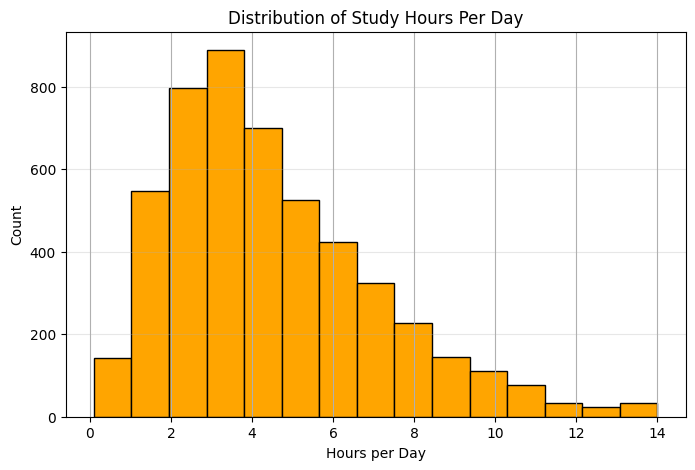

In [32]:
# Study_Hours_Per_Day-ի հիստոգրամ
plt.figure(figsize=(8, 5))
df['Study_Hours_Per_Day'].hist(bins=15, color='orange', edgecolor='black')
plt.title('Distribution of Study Hours Per Day')
plt.xlabel('Hours per Day')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3) # Ավելացնում է թեթև ցանց
plt.show()

## Distribution of Final CGPA
Visualizing how students' grades are distributed.

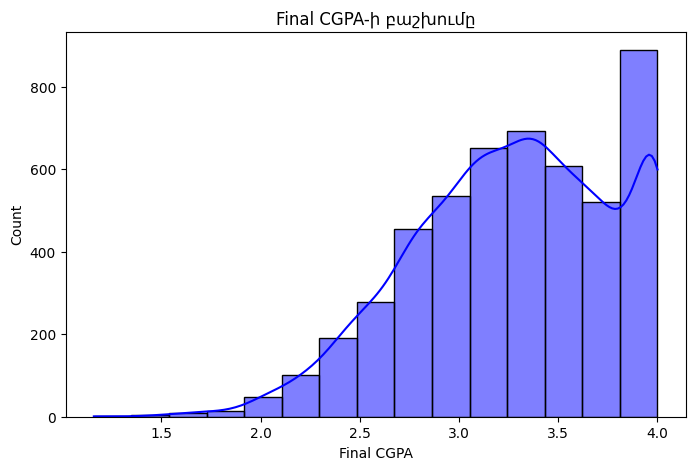

In [33]:
plt.figure(figsize=(8, 5))
# kde=True-ն ցույց է տալիս բաշխման ձևը (skewness)
sns.histplot(df['Final_CGPA'], kde=True, color='blue', bins=15)
plt.title('Final CGPA-ի բաշխումը')
plt.xlabel('Final CGPA')
plt.ylabel('Count')
plt.show()

## Outlier Detection
Using a boxplot to identify any unusual data points in CGPA.

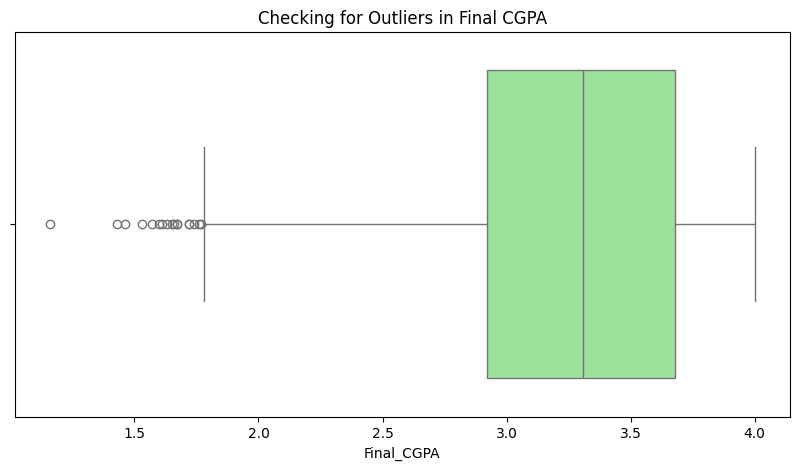

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Final_CGPA'], color='lightgreen')
plt.title('Checking for Outliers in Final CGPA')
plt.show()

## Correlation Analysis: Exploring Relationships Between Variables
In this section, we use a Correlation Heatmap to see how different factors are linked.
* **Positive Correlation (closer to 1):** Variables increase together.
* **Negative Correlation (closer to -1):** One variable increases as the other decreases.
* **No Correlation (0):** No linear relationship.

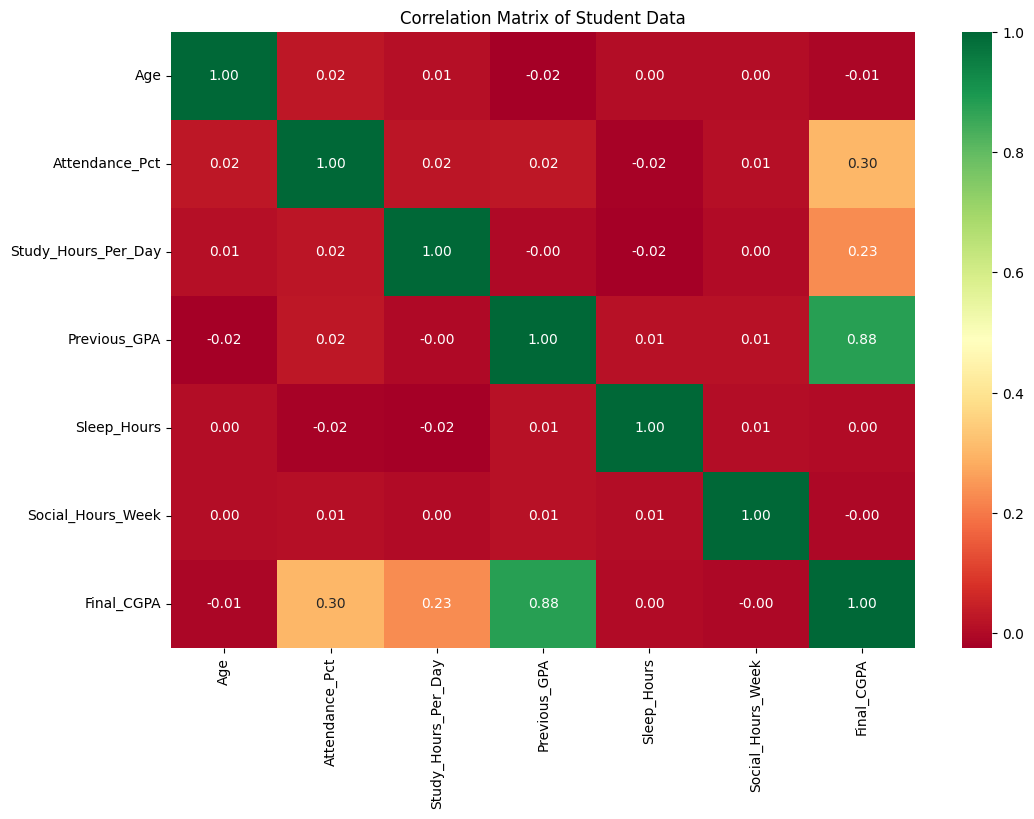

In [38]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix of Student Data')
plt.show()

## Relationship: Study Hours vs Final CGPA

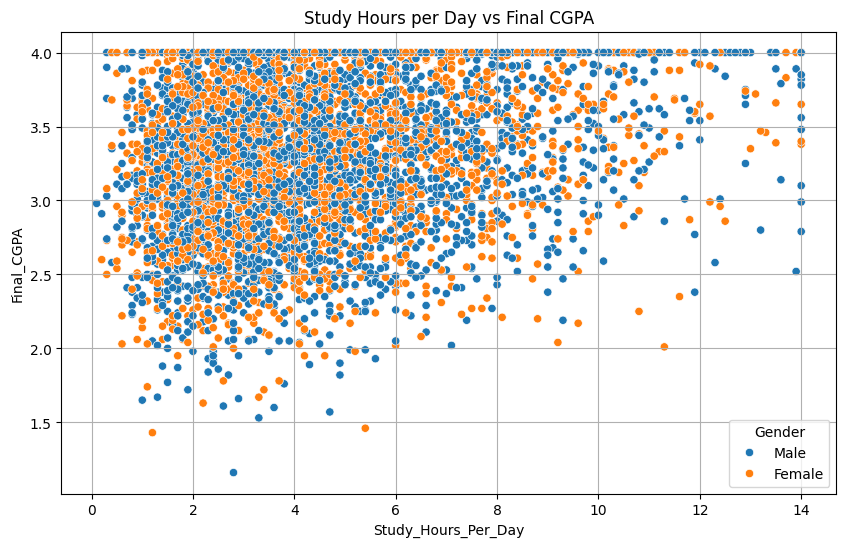

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Study_Hours_Per_Day', y='Final_CGPA', data=df, hue='Gender')
plt.title('Study Hours per Day vs Final CGPA')
plt.grid(True)
plt.show()

## Conclusion & Future Work
### Key Insights:
* **Academic Success:** Students who study more hours tend to have a higher Final_CGPA.
* **Data Quality:** The dataset is clean with no significant missing values.
* **Outliers:** Some outliers exist in the lower CGPA range, which requires further investigation.

### Final Project Direction:
I plan to build a **Linear Regression model** to predict Final_CGPA based on study hours, attendance, and other habits.